## 1. Setup and Imports

In [1]:
try:
    import torch_dct
except ImportError:
    !pip install torch_dct
    !pip install huffman
    !apt-get update && apt-get install -y ffmpeg

Get:1 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:2 http://archive.ubuntu.com/ubuntu jammy InRelease                         
Get:3 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]        
Get:4 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:5 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2004/x86_64  InRelease [1,581 B]
Get:6 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,708 kB]
Get:7 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [6,468 kB]
Get:8 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,299 kB]
Get:9 http://archive.ubuntu.com/ubuntu jammy-updates/restricted amd64 Packages [6,688 kB]
Get:10 http://security.ubuntu.com/ubuntu jammy-security/multiverse amd64 Packages [62.6 kB]
Get:11 http://archive.ubuntu.com/ubuntu jammy-updates/multiverse amd64 Packages [70.9 kB]
Get:12 http://archive.ubuntu.com/ubuntu jammy-upda

In [2]:
# Add project root to path
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))
print(f"Added {project_root} to Python path")

Added /myhome/sdate to Python path


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from pathlib import Path
import lovely_tensors as lt
from tqdm.auto import tqdm

# Import our dataset classes
from sdate.datasets.projection_triplet_dataset import (
    ProjectionTripletDataset,
    TomographyFolderProcessor,
    create_train_val_split,
    load_tomography_params
)

# Set up lovely_tensors for better tensor visualization
lt.monkey_patch()

# Set up matplotlib
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['image.cmap'] = 'gray'

print("✅ Libraries imported successfully!")

Matplotlib is building the font cache; this may take a moment.
/opt/conda/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Install with: pip install pillow-heif
✅ Libraries imported successfully!


## 2. Configure Data Paths

Set the path(s) to your tomographic data folders. Each folder should contain:
- Dark field images (first `num_darks` files)
- Flat field images (next `num_flats` files)
- Projection images (remaining files)

In [4]:
# Configuration
# =============

# Multiple folder example
DATA_PATH = [Path(f'/myhome/data/sdate/shared/compression_paper/file_{i}_extracted') for i in range(1, 13)]

# Or single folder (uncomment and modify as needed)
# DATA_PATH = Path('/myhome/data/sdate/shared/compression_paper/file_9_extracted')

# Processing parameters
TARGET_SIZE = 512  # Standardized output size

# Check if paths exist and auto-detect tomography parameters
if isinstance(DATA_PATH, list):
    # Multiple folders
    valid_paths = [p for p in DATA_PATH if p.exists()]
    print(f"✅ Found {len(valid_paths)} valid folders out of {len(DATA_PATH)}")
    
    for path in valid_paths[:3]:  # Show first 3
        tiff_files = sorted(list(path.glob('*.tif')) + list(path.glob('*.tiff')))
        print(f"   - {path.name}: {len(tiff_files)} TIFF files")
    
    if len(valid_paths) > 3:
        print(f"   ... and {len(valid_paths) - 3} more folders")
    
    # Auto-detect parameters from first folder
    if valid_paths:
        tomo_params = load_tomography_params(valid_paths[0])
        NUM_DARKS = tomo_params.get('num_darks', 10)
        NUM_FLATS = tomo_params.get('num_flats', 10)
        NUM_PROJECTIONS = tomo_params.get('num_projections', 10)
        
        print(f"\n📊 Using parameters from {valid_paths[0].name}:")
        print(f"   Darks: {NUM_DARKS}")
        print(f"   Flats: {NUM_FLATS}")
        print(f"   Projections per folder: {NUM_PROJECTIONS}")
    else:
        print("❌ No valid folders found")
        NUM_DARKS = 10
        NUM_FLATS = 10
        NUM_PROJECTIONS = 0
else:
    # Single folder
    if DATA_PATH.exists():
        tiff_files = sorted(list(DATA_PATH.glob('*.tif')) + list(DATA_PATH.glob('*.tiff')))
        print(f"✅ Found {len(tiff_files)} TIFF files in {DATA_PATH.name}")
        
        # Auto-detect num_darks and num_flats from log file
        tomo_params = load_tomography_params(DATA_PATH)
        NUM_DARKS = tomo_params.get('num_darks', 10)
        NUM_FLATS = tomo_params.get('num_flats', 10)
        NUM_PROJECTIONS = tomo_params.get('num_projections', 10)
        
        print(f"\n📊 Detected tomography parameters:")
        print(f"   Darks: {NUM_DARKS}")
        print(f"   Flats: {NUM_FLATS}")
        print(f"   Projections: {NUM_PROJECTIONS}")
    else:
        print(f"❌ Path not found: {DATA_PATH}")
        print("   Please update DATA_PATH to point to your data folder.")
        NUM_DARKS = 10  # Fallback defaults
        NUM_FLATS = 10
        NUM_PROJECTIONS = 0

✅ Found 12 valid folders out of 12
   - file_1_extracted: 1711 TIFF files
   - file_2_extracted: 1711 TIFF files
   - file_3_extracted: 751 TIFF files
   ... and 9 more folders
✅ Found parameters in JC_62d.log: {'num_darks': 10, 'num_flats': 100, 'num_projections': 1501}

📊 Using parameters from file_1_extracted:
   Darks: 10
   Flats: 100
   Projections per folder: 1501


## 3. Understanding the TomographyFolderProcessor

The `TomographyFolderProcessor` handles loading and preprocessing of tomographic data from a single folder.

In [5]:
# Create a folder processor for the first folder (for demonstration)
# Note: num_darks and num_flats can be set to None for auto-detection from log file

# Get the first valid folder
if isinstance(DATA_PATH, list):
    demo_folder = valid_paths[0] if valid_paths else None
else:
    demo_folder = DATA_PATH if DATA_PATH.exists() else None

if demo_folder is None:
    print("❌ No valid folders available")
else:
    processor = TomographyFolderProcessor(
        folder_path=demo_folder,
        num_darks=None,  # Auto-detect from log file
        num_flats=None,  # Auto-detect from log file
        epsilon=1e-6,
        cache_in_memory=False,  # Set to True for faster repeated access
        verbose=True,
        use_attenuation=False
    )
    
    print(f"\n📊 Folder Statistics:")
    print(f"   Original image size: {processor.original_width} × {processor.original_height}")
    print(f"   Number of projections: {processor.num_projections}")
    print(f"   Data type: {processor.dtype}")

✅ Found parameters in JC_62d.log: {'num_darks': 10, 'num_flats': 100, 'num_projections': 1501}


📂 Loaded folder: file_1_extracted
   Total TIFF files: 1711
   Darks: 10, Flats: 100, Projections: 1501
   Image dimensions: 2560 x 2160
   Use attenuation: False
✅ Loaded cached raw data from .tomography_cache_raw.npz
   Range: [6814.0000, 51523.0000]

📊 Folder Statistics:
   Original image size: 2560 × 2160
   Number of projections: 1501
   Data type: uint16


In [6]:
# Compute the range from the projections
if demo_folder is not None:
    global_min, global_max = processor.compute_range(
        sample_ratio=0.2,  # Sample 20% of projections
        max_samples=None
    )
    
    print(f"\n📈 Projection Range:")
    print(f"   Min: {global_min:.4f}")
    print(f"   Max: {global_max:.4f}")
    print(f"   Range: {global_max - global_min:.4f}")


📈 Projection Range:
   Min: 6814.0000
   Max: 51523.0000
   Range: 44709.0000


Projection 661:
  Shape: (2160, 2560)
  Range: [7282.0000, 46804.0000]


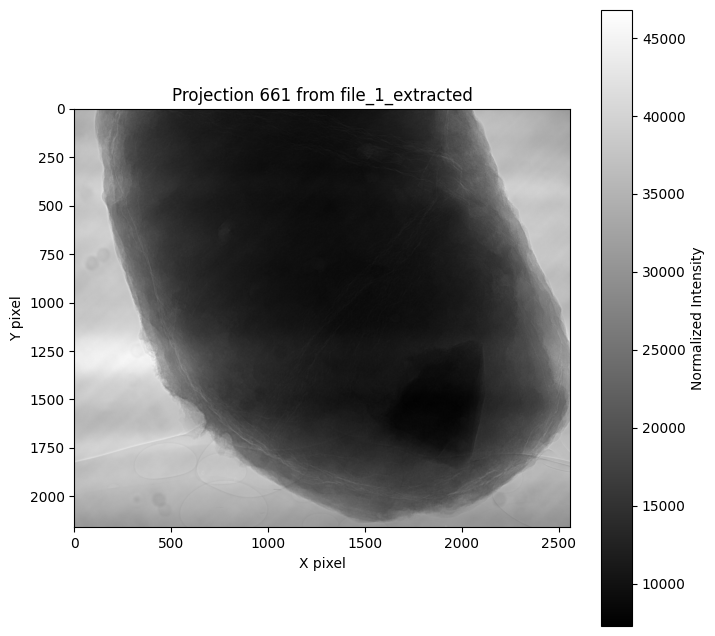

In [7]:
# Load and visualize a single projection
if demo_folder is not None:
    proj_idx = min(661, processor.num_projections - 1)  # Choose a projection index
    
    # Get the projection (normalized to [0, 1])
    projection = processor.get_projection(proj_idx, normalize=False)
    
    print(f"Projection {proj_idx}:")
    print(f"  Shape: {projection.shape}")
    print(f"  Range: [{projection.min():.4f}, {projection.max():.4f}]")
    
    # Visualize
    plt.figure(figsize=(8, 8))
    plt.imshow(projection)
    plt.colorbar(label='Normalized Intensity')
    plt.title(f'Projection {proj_idx} from {demo_folder.name}')
    plt.xlabel('X pixel')
    plt.ylabel('Y pixel')
    plt.show()

## 4. Creating the Dataset

The `ProjectionTripletDataset` creates sequences of consecutive projections for Noise2Noise training:
- **Input**: Stack of k consecutive projections P_i, P_{i+1}, ..., P_{i+k-1} (k channels)
- **Target**: Next projection P_{i+k} (1 channel)

The number of input projections k is controlled by the `num_input_projections` parameter (default=2).

In [8]:
# Create the dataset
# Note: num_darks and num_flats can be set to None for auto-detection from log file

NUM_INPUT_PROJECTIONS = 3  # Number of input channels (k). Target is the (k+1)-th projection.

dataset = ProjectionTripletDataset(
    folder_paths=DATA_PATH,
    target_size=TARGET_SIZE,
    num_darks=None,  # Auto-detect from log file
    num_flats=None,  # Auto-detect from log file
    epsilon=1e-6,
    cache_in_memory=False,
    preload=False,
    augment=False,  # Set to True for training
    verbose=True,
    use_attenuation=False,
    num_input_projections=NUM_INPUT_PROJECTIONS
)

print(f"\n📊 Dataset Statistics:")
print(f"   Total samples: {len(dataset)}")
print(f"   Input projections per sample (k): {NUM_INPUT_PROJECTIONS}")
print(f"   Target size: {TARGET_SIZE} × {TARGET_SIZE}")

✅ Found parameters in JC_62d.log: {'num_darks': 10, 'num_flats': 100, 'num_projections': 1501}
📂 Loaded folder: file_1_extracted
   Total TIFF files: 1711
   Darks: 10, Flats: 100, Projections: 1501
   Image dimensions: 2560 x 2160
   Use attenuation: False
✅ Loaded cached raw data from .tomography_cache_raw.npz
   Range: [6814.0000, 51523.0000]
✅ Found parameters in PD1511_41_.log: {'num_darks': 10, 'num_flats': 100, 'num_projections': 1501}
📂 Loaded folder: file_2_extracted
   Total TIFF files: 1711
   Darks: 10, Flats: 100, Projections: 1501
   Image dimensions: 2560 x 2160
   Use attenuation: False
✅ Loaded cached raw data from .tomography_cache_raw.npz
   Range: [5944.0000, 52770.0000]
✅ Found parameters in MI04_02.log: {'num_darks': 50, 'num_flats': 100, 'num_projections': 501}
📂 Loaded folder: file_3_extracted
   Total TIFF files: 751
   Darks: 50, Flats: 100, Projections: 501
   Image dimensions: 1008 x 1900
   Use attenuation: False
✅ Loaded cached raw data from .tomography_ca

✅ Found parameters in FC_13p5keV_G_LAG100_4ms_70mm_1000p.log: {'num_darks': 10, 'num_flats': 100, 'num_projections': 1001}
📂 Loaded folder: file_4_extracted
   Total TIFF files: 1211
   Darks: 10, Flats: 100, Projections: 1001
   Image dimensions: 2016 x 300
   Use attenuation: False
✅ Loaded cached raw data from .tomography_cache_raw.npz
   Range: [0.0000, 4095.0000]
✅ Found parameters in FC_13p5keV_G_LAG100_0p5ms_70mm_400p.log: {'num_darks': 10, 'num_flats': 100, 'num_projections': 401}
📂 Loaded folder: file_5_extracted
   Total TIFF files: 611
   Darks: 10, Flats: 100, Projections: 401
   Image dimensions: 2016 x 300
   Use attenuation: False
✅ Loaded cached raw data from .tomography_cache_raw.npz
   Range: [0.0000, 785.0000]
✅ Found parameters in B007_1_17p5keVb.log: {'num_darks': 10, 'num_flats': 100, 'num_projections': 1501}
📂 Loaded folder: file_6_extracted
   Total TIFF files: 1711
   Darks: 10, Flats: 100, Projections: 1501
   Image dimensions: 2560 x 2160
   Use attenuation: 

/tmp/ipykernel_12691/4169138367.py:32: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  vmax_diff = np.abs(diff).max()


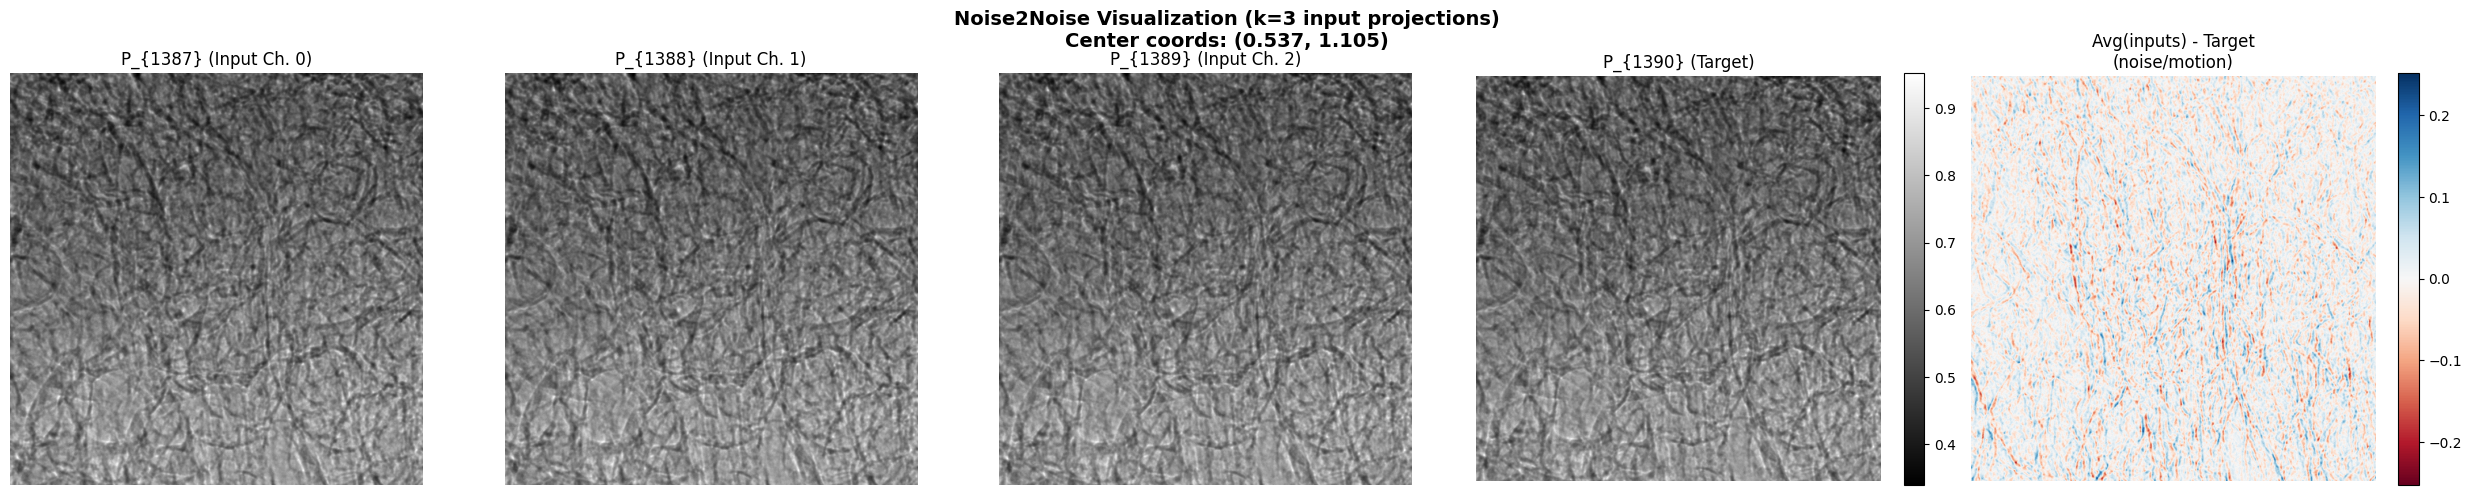

In [9]:
import random
# Get a sample from the dataset
sample_idx = random.randint(0, len(dataset) - 1)
sample = dataset[sample_idx]

# Visualize the input projections and target
k = NUM_INPUT_PROJECTIONS
num_cols = k + 2  # k input channels + target + difference
fig, axes = plt.subplots(1, num_cols, figsize=(5 * num_cols, 5))

range_min = sample['input'].min()
range_max = sample['input'].max()

target_proj_idx = sample['projection_idx']

# Plot each input channel
for ch in range(k):
    axes[ch].imshow(sample['input'][ch].numpy(), vmin=range_min, vmax=range_max)
    input_proj_idx = target_proj_idx - k + ch
    axes[ch].set_title(f'P_{{{input_proj_idx}}} (Input Ch. {ch})')
    axes[ch].axis('off')

# Target projection
im_target = axes[k].imshow(sample['target'][0].numpy(), vmin=range_min, vmax=range_max)
axes[k].set_title(f'P_{{{target_proj_idx}}} (Target)')
axes[k].axis('off')
plt.colorbar(im_target, ax=axes[k], fraction=0.046)

# Difference between average of inputs and target
input_avg = sample['input'][0]
diff = input_avg - sample['target'][0]
vmax_diff = np.abs(diff).max()
im_diff = axes[k + 1].imshow(diff, cmap='RdBu', vmin=-vmax_diff, vmax=vmax_diff)
axes[k + 1].set_title(f'Avg(inputs) - Target\n(noise/motion)')
axes[k + 1].axis('off')
plt.colorbar(im_diff, ax=axes[k + 1], fraction=0.046)

plt.suptitle(f'Noise2Noise Visualization (k={k} input projections)\nCenter coords: ({sample["center_coords"][0]:.3f}, {sample["center_coords"][1]:.3f})', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
from ipywidgets import interact, FloatSlider
import torch.nn.functional as F

@interact(offset_x=FloatSlider(min=-5.0, max=5.0, step=0.1, value=0.0, description='Offset X (px)'),
          offset_y=FloatSlider(min=-5.0, max=5.0, step=0.1, value=0.0, description='Offset Y (px)'))
def visualize_offset(offset_x, offset_y):
    """
    Visualize how sub-pixel shifting of the last input frame affects the difference with target.
    
    Args:
        offset_x: Horizontal offset in pixels (-5 to +5)
        offset_y: Vertical offset in pixels (-5 to +5)
    """
    # Get the last input frame and target
    last_input = sample['input'][-1]  # Shape: (H, W)
    target = sample['target'][0]
    
    # Convert to torch tensors for interpolation
    last_input_t = last_input.unsqueeze(0).unsqueeze(0)
    target_t = target.unsqueeze(0).unsqueeze(0)
    
    # Create affine transformation matrix for translation
    # Normalize offset to [-1, 1] range (required by affine_grid)
    H, W = last_input.shape
    tx = 2 * offset_x / W  # Normalize to [-1, 1]
    ty = 2 * offset_y / H
    
    # Affine matrix: [[1, 0, tx], [0, 1, ty]]
    theta = torch.tensor([[[1.0, 0.0, tx],
                           [0.0, 1.0, ty]]], dtype=torch.float32)
    
    # Apply transformation
    grid = F.affine_grid(theta, last_input_t.size(), align_corners=False)
    shifted = F.grid_sample(last_input_t, grid, mode='bilinear', padding_mode='border', align_corners=False)
    
    # Compute difference
    diff = shifted - target_t
    
    # Convert back to numpy for visualization
    shifted_np = shifted[0, 0].cpu().numpy()
    diff_np = diff[0, 0].cpu().numpy()
    target_np = target.numpy()
    
    # Compute overall metrics
    mse = np.mean(diff_np ** 2)
    psnr = 10 * np.log10(1.0 / max(mse, 1e-10))
    
    # Compute 95th percentile threshold on absolute difference
    abs_diff = np.abs(diff_np)
    threshold_95 = np.percentile(abs_diff, 95)
    
    # Create masks for below and above 95th percentile
    mask_below_95 = abs_diff <= threshold_95
    mask_above_95 = abs_diff > threshold_95
    
    # Compute MSE and PSNR for pixels below 95th percentile
    if mask_below_95.sum() > 0:
        mse_below_95 = np.mean(diff_np[mask_below_95] ** 2)
        psnr_below_95 = 10 * np.log10(1.0 / max(mse_below_95, 1e-10))
    else:
        mse_below_95 = 0.0
        psnr_below_95 = float('inf')
    
    # Compute MSE and PSNR for pixels above 95th percentile
    if mask_above_95.sum() > 0:
        mse_above_95 = np.mean(diff_np[mask_above_95] ** 2)
        psnr_above_95 = 10 * np.log10(1.0 / max(mse_above_95, 1e-10))
    else:
        mse_above_95 = 0.0
        psnr_above_95 = float('inf')
    
    # Visualize
    fig, axes = plt.subplots(1, 4, figsize=(22, 5))
    
    # Shifted input
    axes[0].imshow(shifted_np, vmin=0, vmax=1)
    axes[0].set_title(f'Shifted Input\n(Δx={offset_x:.1f}px, Δy={offset_y:.1f}px)')
    axes[0].axis('off')
    
    # Target
    axes[1].imshow(target_np, vmin=0, vmax=1)
    axes[1].set_title('Target')
    axes[1].axis('off')
    
    # Difference
    vmax = max(np.abs(diff_np).max(), 1e-6)
    im = axes[2].imshow(diff_np, cmap='RdBu', vmin=-vmax, vmax=vmax)
    axes[2].set_title(f'Difference (Shifted - Target)\nMSE: {mse:.6f}, PSNR: {psnr:.2f} dB')
    axes[2].axis('off')
    plt.colorbar(im, ax=axes[2], fraction=0.046)
    
    # Mask visualization: show pixels above 95th percentile
    mask_viz = np.zeros((*diff_np.shape, 3))
    mask_viz[..., 0] = mask_above_95.astype(float)  # Red channel for above 95th
    mask_viz[..., 2] = mask_below_95.astype(float) * 0.3  # Blue channel (dimmed) for below 95th
    axes[3].imshow(mask_viz)
    axes[3].set_title(f'95th Percentile Mask\nRed: top 5% ({mask_above_95.sum()} px)')
    axes[3].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"Offset: ({offset_x:+.1f}px, {offset_y:+.1f}px)")
    print(f"\n{'='*60}")
    print(f"{'Metric':<25} {'Overall':>12} {'Below 95%':>12} {'Above 95%':>12}")
    print(f"{'-'*60}")
    print(f"{'MSE':<25} {mse:>12.8f} {mse_below_95:>12.8f} {mse_above_95:>12.8f}")
    print(f"{'PSNR (dB)':<25} {psnr:>12.2f} {psnr_below_95:>12.2f} {psnr_above_95:>12.2f}")
    print(f"{'Pixel Count':<25} {diff_np.size:>12} {mask_below_95.sum():>12} {mask_above_95.sum():>12}")
    print(f"{'='*60}")
    print(f"\n95th percentile threshold: {threshold_95:.6f}")
    print(f"Max absolute error: {np.abs(diff_np).max():.6f}")

interactive(children=(FloatSlider(value=0.0, description='Offset X (px)', max=5.0, min=-5.0), FloatSlider(valu…

In [11]:
## 8. Model Setup (UNet2DModel from Diffusers)

In [12]:
from diffusers import UNet2DModel

# Create the UNet model
model = UNet2DModel(
    sample_size=TARGET_SIZE,  # the target image resolution
    in_channels=NUM_INPUT_PROJECTIONS,  # k input channels: P_i, P_{i+1}, ..., P_{i+k-1}
    out_channels=1,  # 1 output channel: predicted P_{i+k}
    layers_per_block=2,  # ResNet layers per UNet block
    block_out_channels=(64, 64, 128, 128, 256, 256),  # channels for each block
    down_block_types=(
        "DownBlock2D",
        "DownBlock2D",
        "DownBlock2D",
        "DownBlock2D",
        "AttnDownBlock2D",  # attention block
        "DownBlock2D",
    ),
    up_block_types=(
        "UpBlock2D",
        "AttnUpBlock2D",  # attention block
        "UpBlock2D",
        "UpBlock2D",
        "UpBlock2D",
        "UpBlock2D",
    ),
)

# Count parameters
num_params = sum(p.numel() for p in model.parameters())
num_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"🏗️  Model Summary:")
print(f"   Total parameters: {num_params:,}")
print(f"   Trainable parameters: {num_trainable:,}")
print(f"   Input channels: {NUM_INPUT_PROJECTIONS}")
print(f"   Output channels: 1")
print(f"   Sample size: {TARGET_SIZE}×{TARGET_SIZE}")

# Load trained model weights if available
checkpoint_path = Path("../checkpoints/best_model.pt")
if checkpoint_path.exists():
    print(f"\n📂 Loading trained model from {checkpoint_path}")
    checkpoint = torch.load(checkpoint_path, map_location='cpu')
    model.load_state_dict(checkpoint['model_state_dict'])
    epoch = checkpoint['epoch']
    val_loss = checkpoint.get('best_val_loss', 'N/A')
    print(f"   ✅ Loaded checkpoint from epoch {epoch}")
    print(f"   Validation loss: {val_loss}")
else:
    print(f"\n⚠️  No trained model found at {checkpoint_path}")
    print(f"   Using untrained model (random weights)")

# Test forward pass
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

model = model.to(device)

🏗️  Model Summary:
   Total parameters: 28,446,081
   Trainable parameters: 28,446,081
   Input channels: 3
   Output channels: 1
   Sample size: 512×512

📂 Loading trained model from ../checkpoints/best_model.pt
   ✅ Loaded checkpoint from epoch 24
   Validation loss: 0.001245795919708649
Device: cuda


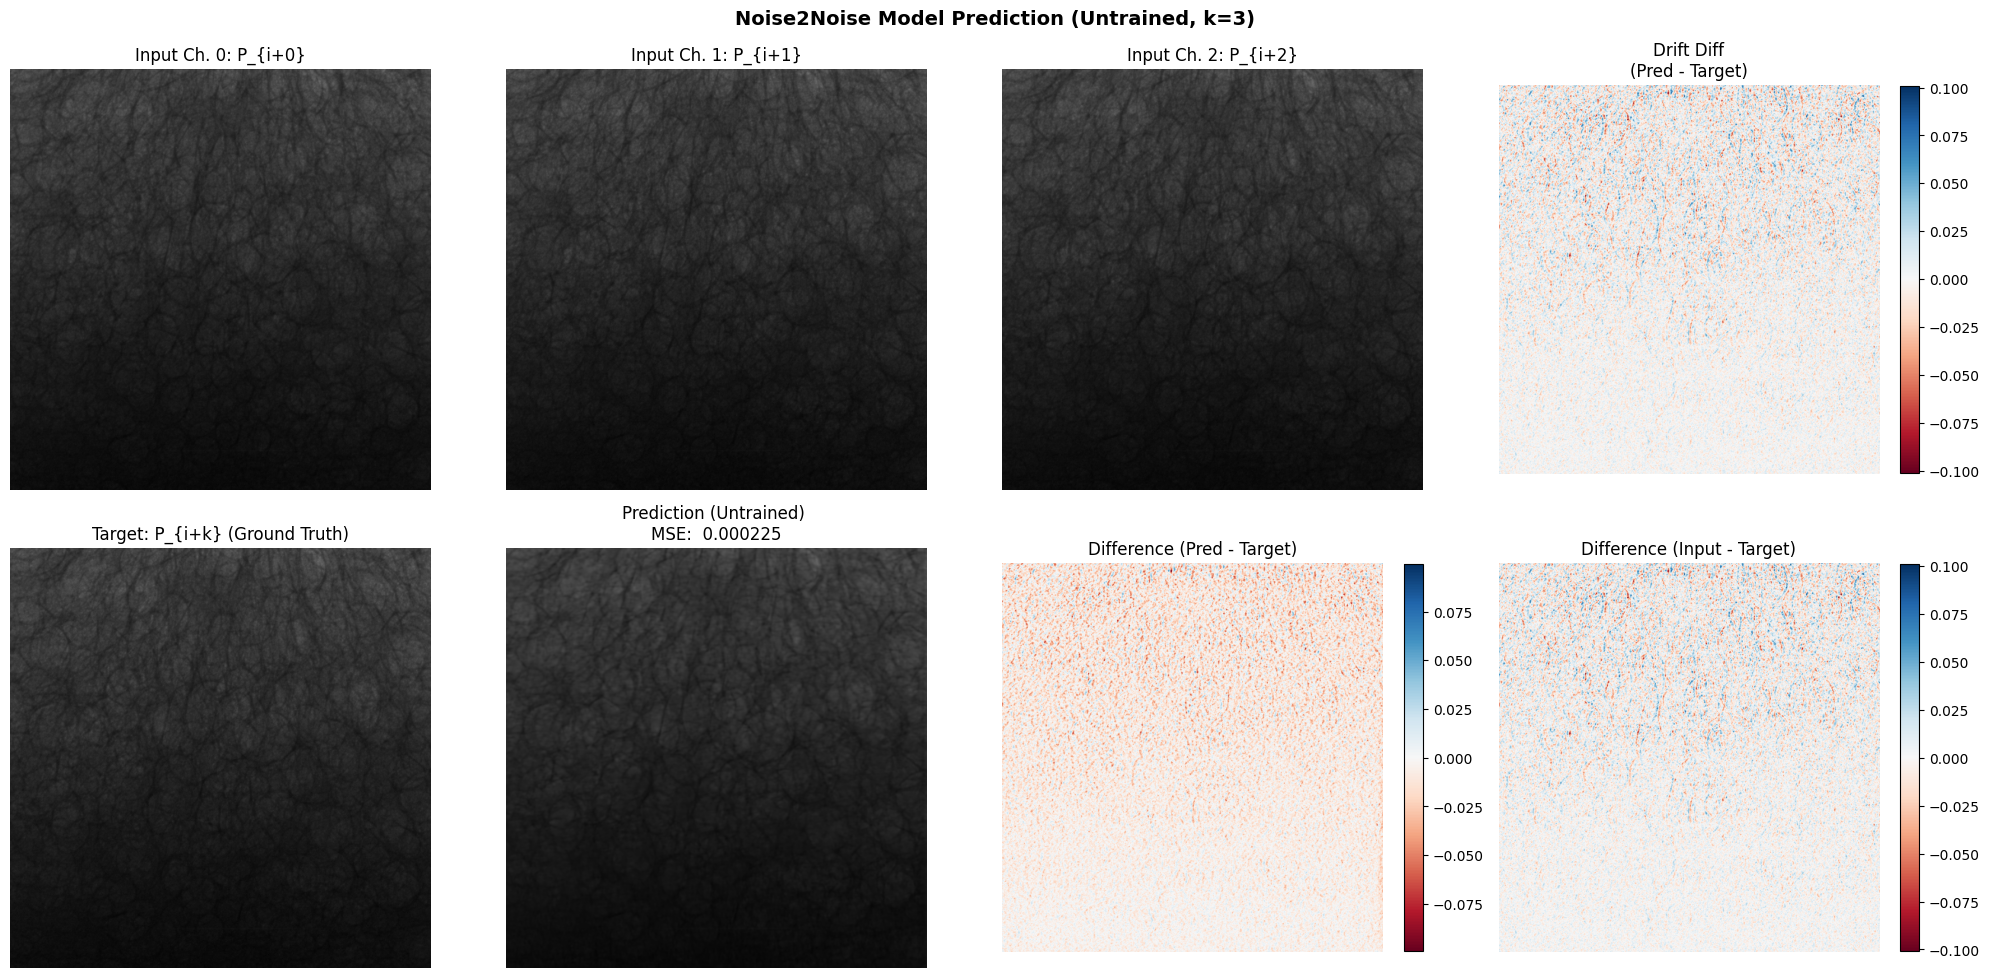

In [13]:
# Get a prediction from the (mostly untrained) model
model.eval()
DRIFT_MODES = ["phase_correlation", "optical_flow", "cross_correlation"]
with torch.no_grad():
    sample = dataset[3028]
    input_tensor = sample['input'].unsqueeze(0).to(device)
    target_tensor = sample['target'].unsqueeze(0).to(device)
    center_coords = sample['center_coords'].unsqueeze(0).to(device)  # (B, 2)
    conditioning = center_coords[:, 0].long()  # Use the first coordinate as timestep to condition on the x position
    
    # conditioning = torch.zeros(1, dtype=torch.long, device=device)
    
    pred = model(input_tensor, conditioning, return_dict=False)[0]
    
    # Compute MSE
    mse = torch.nn.functional.mse_loss(pred, target_tensor).item()

# Get drift predictor prediction (phase correlation)
from compress_ct.drift_predictor import DriftPredictor
drift_pred = DriftPredictor(mode=DRIFT_MODES[2], num_input_projections=NUM_INPUT_PROJECTIONS, verbose=False)
prev_frames = [sample['input'][i].numpy() for i in range(NUM_INPUT_PROJECTIONS)]
drift_prediction = drift_pred.predict_frame(prev_frames)

# Visualize
k = NUM_INPUT_PROJECTIONS
num_top_cols = k + 1  # k inputs + average
num_bot_cols = 3      # target, prediction, difference
num_cols = max(num_top_cols, num_bot_cols)
fig, axes = plt.subplots(2, num_cols, figsize=(5 * num_cols, 10))

# Hide unused axes
for ax_row in axes:
    for ax in ax_row:
        ax.axis('off')

# Top row: input channels + average
for ch in range(k):
    axes[0, ch].imshow(sample['input'][ch].numpy(), vmin=0, vmax=1)
    axes[0, ch].set_title(f'Input Ch. {ch}: P_{{i+{ch}}}')
    axes[0, ch].axis('off')
padding = 6
# Drift difference
diff_drift = (drift_prediction[:, padding:-padding] - sample['target'][0][:, padding:-padding].numpy())
vmax_drift = np.abs(diff_drift).max()
im = axes[0, k].imshow(diff_drift, cmap='RdBu', vmin=-vmax_drift, vmax=vmax_drift)
axes[0, k].set_title('Drift Diff\n(Pred - Target)')
axes[0, k].axis('off')
plt.colorbar(im, ax=axes[0, k], fraction=0.046)

# Bottom row: target, prediction, difference
axes[1, 0].imshow(sample['target'][0].numpy(), vmin=0, vmax=1)
axes[1, 0].set_title('Target: P_{i+k} (Ground Truth)')
axes[1, 0].axis('off')

im = axes [1, 1]. imshow(pred [0, 0] .cpu().numpy(), vmin=0, vmax=1)
axes [1, 1]. imshow(pred [0, 0].cpu( ).numpy(), vmin=0, vmax=1)
axes [1, 1].set_title(f'Prediction (Untrained) \nMSE: {mse: .6f}')
axes [1, 1].axis( 'off')
# Difference

diff = (pred[0, 0, :, padding:-padding].cpu() - sample['target'][0][:, padding:-padding]).numpy()
vmax = np.abs(diff).max()
im = axes[1, 2].imshow(diff, cmap='RdBu', vmin=-vmax, vmax=vmax)
axes[1, 2].set_title('Difference (Pred - Target)')
axes[1, 2].axis('off')
plt.colorbar(im, ax=axes[1, 2], fraction=0.046)

diff2 = (sample['input'][-1][:, padding:-padding] - sample['target'][0][:, padding:-padding]).numpy()
vmax = np.abs(diff2).max()
im = axes[1, 3].imshow(diff2, cmap='RdBu', vmin=-vmax, vmax=vmax)
axes[1, 3].set_title('Difference (Input - Target)')
axes[1, 3].axis('off')
plt.colorbar(im, ax=axes[1, 3], fraction=0.046)

plt.suptitle(f'Noise2Noise Model Prediction (Untrained, k={k})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()